# Задача построения профилей клиентов платежной системы

Аналитическая задача — провести анализ данных с целью выделения наиболее типичных групп клиентов.

Каждый клиент описывается следующим набором признаков:

 mdm_id                       Идентификатор

BIRTHDAY                Дата рождения

CREDCODE              Кредитный код

1.1                                Дисциплина клиентов без просрочки

1.2                                Дисциплина клиентов с редкими просрочками

2.1                                Количество переводов

2.1.1                             Количество переводов до 1 смс

2.1.2                             Количество переводов после 1 смс

2.1.3                             Количество переводов до взятия кредита

2.1.4                             Количество переводов после взятия кредита

2.2                                Тип переводов

2.3                                География переводов

2.4                                География телефона

2.5                                Сумма перевода

2.5.1                             Максимальная сумма перевода

2.5.2                             Средняя сумма перевода

2.5.3                             Полная сумма перевода

2.5.4                             Сумма перевода за полгода до взятия кредита

2.5.5                             Сумма перевода за год до взятия кредита

4                                   Канал, через который пришел клиент

5.1                                Количество смс до отклика

5.2                                Дней с первой смс

5.6                                Оператор связи

6.1                                Возраст

6.2                                Пол

6.5                                Совпал ли регион получения кредита с регионом телефона

6.6                                Указал иной номер телефона при выдаче кредита

# Загрузка и чтение данных из файла

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Data-анализ_2/modile.xlsx')
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1,2.1.1,2.1.2,2.1.3,2.1.4,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,17.0,0.0,0.0,12.0,5.0,...,268000.0,271000.0,Стойка,NaN,NaN,NaN,33.0,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,4.0,0.0,0.0,2.0,2.0,...,135150.0,137574.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,3.0,0.0,0.0,1.0,2.0,...,135150.0,135150.0,Стойка,NaN,NaN,МегаФон,57.0,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,3.0,0.0,0.0,1.0,2.0,...,50150.0,50150.0,Стойка,NaN,NaN,NaN,36.0,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,5.0,0.0,0.0,2.0,3.0,...,135150.0,135150.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,5947389,1977-10-28,9022,BAD,A,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,NaN,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,NaN,NaN,NaN,31.0,М,1,1.0


# Очистка и форматирование данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50224 entries, 0 to 50223
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   mdm_id    50224 non-null  int64         
 1   BIRTHDAY  50224 non-null  datetime64[ns]
 2   CREDCODE  50224 non-null  int64         
 3   1.1       50223 non-null  object        
 4   1.2       39938 non-null  object        
 5   2.1       50158 non-null  float64       
 6   2.1.1     50158 non-null  float64       
 7   2.1.2     50158 non-null  float64       
 8   2.1.3     50158 non-null  float64       
 9   2.1.4     50158 non-null  float64       
 10  2.2       50191 non-null  float64       
 11  2.3       50191 non-null  float64       
 12  2.4       48324 non-null  float64       
 13  2.5       50158 non-null  float64       
 14  2.5.1     50158 non-null  float64       
 15  2.5.2     50158 non-null  float64       
 16  2.5.3     50158 non-null  float64       
 17  2.5.4     50

In [ ]:
#Посмотрю, в каких столбцах есть пропуски
df.isna().sum()

,0
mdm_id,0
BIRTHDAY,0
CREDCODE,0
1.1,1
1.2,10286
2.1,66
2.1.1,66
2.1.2,66
2.1.3,66
2.1.4,66


In [ ]:
#Посмотрю на пропуск в столбце 1.1 "Дисциплина клиентов без просрочки"
df[df['1.1'].isna()]

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1,2.1.1,2.1.2,2.1.3,2.1.4,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
45711,15806303,1963-06-27,9022,NaN,A,23.0,1.0,22.0,1.0,22.0,...,23600.0,23600.0,Офис,1.0,2.0,МегаФон,50.0,М,1,1.0


In [ ]:
df['1.1'].unique()

array(['BAD', 'GOOD', 'MIDDLE', nan], dtype=object)

Пока ничего не буду делать с этим столбцом.

In [ ]:
#Посмотрю на пропуски в столбце 1.2 "Дисциплина клиентов с редкими просрочками"
df[df['1.2'].isna()]

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1,2.1.1,2.1.2,2.1.3,2.1.4,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,17.0,0.0,0.0,12.0,5.0,...,268000.0,271000.0,Стойка,NaN,NaN,NaN,33.0,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,4.0,0.0,0.0,2.0,2.0,...,135150.0,137574.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
8,7119607,1969-08-18,9020,BAD,NaN,4.0,0.0,0.0,2.0,2.0,...,135150.0,135150.0,Офис,NaN,NaN,NaN,44.0,Ж,1,1.0
13,2498343,1975-02-18,9023,BAD,NaN,3.0,0.0,0.0,1.0,2.0,...,50150.0,50150.0,Офис,NaN,NaN,NaN,39.0,М,1,1.0
27,16291379,1952-11-28,9020,BAD,NaN,4.0,0.0,0.0,1.0,3.0,...,135150.0,135150.0,Офис,NaN,NaN,NaN,61.0,Ж,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50215,3989680,1955-09-05,9020,BAD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Стойка,NaN,NaN,NaN,58.0,М,0,NaN
50217,6315081,1983-11-03,9020,MIDDLE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,9.0,191.0,МегаФон,30.0,Ж,1,1.0
50219,5593823,1962-12-08,9022,MIDDLE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN


In [ ]:
df['1.2'].unique()

array([nan, 'C', 'A', 'B'], dtype=object)

Тоже пока оставлю как есть.

In [ ]:
#Посмотрю на пропуски в столбце 2.1 "Количество переводов"
df[df['2.1'].isna()]

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1,2.1.1,2.1.2,2.1.3,2.1.4,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
50158,5544447,1962-03-10,9022,MIDDLE,C,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Партнер,9.0,437.0,Мобильные ТелеСистемы,52.0,М,1,1.0
50159,8434303,1979-05-05,9022,BAD,C,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,2.0,60.0,Мобильные ТелеСистемы,35.0,Ж,1,1.0
50160,9657949,1974-02-15,9023,MIDDLE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,3.0,163.0,Мобильные ТелеСистемы,40.0,Ж,1,1.0
50161,12660236,1963-11-17,9022,BAD,B,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,3.0,70.0,Мобильные ТелеСистемы,50.0,Ж,1,1.0
50162,3541321,1990-06-12,9022,BAD,C,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,5.0,186.0,Вымпел-Коммуникации,24.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,5947389,1977-10-28,9022,BAD,A,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,NaN,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Офис,NaN,NaN,NaN,31.0,М,1,1.0


In [ ]:
df['2.1'].unique()

array([1.700e+01, 4.000e+00, 3.000e+00, 5.000e+00, 2.000e+00, 1.500e+01,
       9.000e+00, 3.700e+01, 1.600e+01, 6.000e+00, 7.000e+00, 3.200e+01,
       3.000e+01, 8.000e+00, 1.400e+01, 1.200e+01, 1.000e+00, 1.000e+01,
       3.100e+01, 1.100e+01, 1.300e+01, 2.000e+01, 1.900e+01, 1.800e+01,
       2.200e+01, 4.200e+01, 2.900e+01, 4.500e+01, 6.200e+01, 4.900e+01,
       2.100e+01, 4.700e+01, 6.300e+01, 5.400e+01, 8.900e+01, 7.600e+01,
       5.000e+01, 2.700e+01, 5.900e+01, 8.200e+01, 5.500e+01, 2.500e+01,
       2.600e+01, 9.800e+01, 3.800e+01, 1.390e+02, 4.800e+01, 4.300e+01,
       3.600e+01, 2.400e+01, 1.140e+02, 3.400e+01, 8.100e+01, 2.300e+01,
       6.500e+01, 1.460e+02, 2.020e+02, 2.800e+01, 5.600e+01, 4.600e+01,
       6.900e+01, 1.320e+02, 4.000e+01, 7.700e+01, 7.400e+01, 1.560e+02,
       3.500e+01, 8.400e+01, 8.600e+01, 3.900e+01, 5.200e+01, 6.100e+01,
       6.600e+01, 7.300e+01, 7.500e+01, 1.050e+02, 1.100e+02, 3.300e+01,
       4.100e+01, 4.400e+01, 5.100e+01, 5.300e+01, 

In [ ]:
#Так как количество переводов - целое число, приведу столбцы 2.1, 2.1.1, 2.1.2, 2.1.3, 2.1.4 к целым числам
df[['2.1', '2.1.1', '2.1.2', '2.1.3', '2.1.4']] = df[['2.1', '2.1.1', '2.1.2', '2.1.3', '2.1.4']].fillna(0).astype(int)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1,2.1.1,2.1.2,2.1.3,2.1.4,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,17,0,0,12,5,...,268000.0,271000.0,Стойка,NaN,NaN,NaN,33.0,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,4,0,0,2,2,...,135150.0,137574.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,3,0,0,1,2,...,135150.0,135150.0,Стойка,NaN,NaN,МегаФон,57.0,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,3,0,0,1,2,...,50150.0,50150.0,Стойка,NaN,NaN,NaN,36.0,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,5,0,0,2,3,...,135150.0,135150.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,0,...,NaN,NaN,Офис,NaN,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,0,...,NaN,NaN,Офис,NaN,NaN,NaN,31.0,М,1,1.0


In [ ]:
#Проверю свою гипотезу, что столбец 2.1 = столбец 2.1.1 + столбец 2.1.2 + столбец 2.1.3 + столбец 2.1.4
calculated_sum_4 = df[['2.1.1', '2.1.2', '2.1.3', '2.1.4']].sum(axis=1)
is_equal_4 = calculated_sum_4.equals(df['2.1'])
print(is_equal_4)

False


Столбец 2.1 не является суммой столбцов 2.1.1, 2.1.2, 2.1.3, 2.1.4.

In [ ]:
#Тогда проверю гипотезу, что столбец 2.1 = столбец 2.1.3 + столбец 2.1.4
calculated_sum_2 = df[['2.1.3', '2.1.4']].sum(axis=1)
is_equal_2 = calculated_sum_2.equals(df['2.1'])
print(is_equal_2)

True


Столбец 2.1 "Количество переводов" является суммой столбцов 2.1.3 "Количество переводов до взятия кредита" и 2.1.4 "Количество переводов после взятия кредита".

In [ ]:
#Так как столбец 2.1 является агрегированным для столбцов 2.1.3 и 2.1.4, считаю, что его нужно удалить, чтобы с ним не путаться
df = df.drop('2.1', axis=1)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2.0,...,268000.0,271000.0,Стойка,NaN,NaN,NaN,33.0,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2.0,...,135150.0,137574.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2.0,...,135150.0,135150.0,Стойка,NaN,NaN,МегаФон,57.0,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2.0,...,50150.0,50150.0,Стойка,NaN,NaN,NaN,36.0,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69.0,...,135150.0,135150.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2.0,...,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,NaN,...,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2.0,...,NaN,NaN,Офис,NaN,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44.0,...,NaN,NaN,Офис,NaN,NaN,NaN,31.0,М,1,1.0


In [ ]:
#Посмотрю столбец 2.1.1 "Количество переводов до 1 смс"
df['2.1.1'].unique()

array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   16,   17,   18,   20,   22,   23,   24,
         25,   26,   27,   35,   38,   39,   40,   43,   50,   52,   61,
         63,   66,   73,   75,  105,  110,   15,   19,   21,   28,   29,
         30,   31,   32,   33,   34,   36,   37,   41,   42,   44,   45,
         46,   48,   49,   51,   53,   54,   64,   68,   70,   95,  115,
        126,  132,  144,  159,  216,   47,   55,   56,   58,   59,   60,
         62,   67,   69,   71,   72,   74,   76,   87,  100,  104,  106,
        136,  139,  154,  167,  188,  261,  286,  410,  513, 1041,   57,
         65,   78,   81,   91,   97,   98,  107,  116,  122,  135,  260,
        764,   77,   80,   85,   93,  141,   79,   84,  117,  138,  145,
        190,   88,  111,  121,  151,  157,   83,   96,   99,  123,  171,
        254,   82,  460,   94,  152,  108,  134,  137,  165,  112,  114,
        263,  371,  169,  101,  102,   89,  109,  1

In [ ]:
#Посмотрю столбец 2.1.2 "Количество переводов после 1 смс"
df['2.1.2'].unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117,
       119, 120, 121, 122, 123, 127, 128, 130, 131, 132, 133, 135, 137,
       141, 142, 143, 144, 145, 147, 148, 150, 151, 152, 153, 154, 157,
       158, 162, 163, 165, 166, 170, 171, 172, 173, 174, 175, 176, 177,
       180, 185, 188, 192, 193, 194, 195, 202, 203, 204, 205, 206, 210,
       212, 213, 215, 216, 224, 227, 231, 240, 245, 255, 262, 26

Так как в столбцах 2.1.1 и 2.1.2 полно ненулевых значений, считаю, что эти столбцы пока удалять не стоит.

In [ ]:
#Посмотрю столбец 2.1.3 "Количество переводов до взятия кредита"
df['2.1.3'].unique()

array([  12,    2,    1,    0,   13,    6,    3,   28,    4,    7,   20,
          5,   25,   10,   27,   11,    8,    9,   17,   14,   37,   48,
         34,   30,   36,   60,   44,   80,   61,   15,   26,   70,   85,
         49,   18,   21,   81,   29,   35,  135,   47,   23,  105,   59,
         79,   46,   40,  125,   66,   52,   31,   24,   89,   55,   74,
         72,   39,  100,   19,   16,   51,  107,   98,   38,   33,   65,
        141,   22,   57,   75,   43,   32,   41,   50,   56,   95,   42,
         45,   53,   54,   68,   73,  115,  126,  132,  144,  159,  216,
         58,   62,   63,   67,   69,   71,   76,   87,  104,  136,  139,
        154,  167,  188,  261,  286,  410,  513, 1041,   77,   83,   91,
         97,  116,  122,  260,  765,   86,   88,  137,  142,   78,  120,
        138,  145,  193,   64,   82,   92,  108,  112,  151,  157,   84,
         99,  111,  121,  171,  254,   90,  464,  101,  102,  110,  134,
        146,  175,  118,  148,  263,  382,  106,  1

In [ ]:
#Посмотрю столбец 2.1.4 "Количество переводов после взятия кредита"
df['2.1.4'].unique()

array([  5,   2,   3,   1,   9,   4,   6,  20,  10,   7,   8,  14,  13,
        12,  11,  17,  15,  22,  83,  74,  24,  33,   0,  18,  16,  25,
        30,  21, 143, 136, 150,  27, 190,  69,  32,  52,  40,  72,  64,
       113,  34,  55, 128, 130,  50,  35,  62, 132, 102,  45, 183,  38,
       178,  89,  95, 104,  37, 169, 156,  19, 162,  67,  43, 151,  86,
        77, 105,  28,  70,  68,  63,  58,  59,  76,  36,  23,  26, 124,
       100,  65,  60,  57, 110,  94,  29,  31,  39,  73,  48,  53,  80,
        61,  41,  42,  44,  46,  47,  49, 101,  93, 115, 127, 121, 118,
        99,  71,  51,  54,  56,  66,  75,  79,  81,  87,  90,  84,  85,
        92,  88,  98, 103, 107,  82, 106, 112,  91,  97, 108,  78, 114,
       109, 111, 125, 116, 140, 117, 135, 149, 120, 145, 142, 123, 166,
       131, 185, 119, 167, 147, 161, 138, 158, 129,  96, 174, 172, 159,
       154, 176, 207, 181, 195, 255, 180, 264, 141, 160, 153, 144, 186,
       163, 133, 285, 213, 249, 301, 233, 288, 229, 297, 216, 17

In [ ]:
#Посмотрю на пропуски в столбце 2.2 "Тип переводов"
df[df['2.2'].isna()]

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
50158,5544447,1962-03-10,9022,MIDDLE,C,0,0,0,0,NaN,...,NaN,NaN,Партнер,9.0,437.0,Мобильные ТелеСистемы,52.0,М,1,1.0
50163,2084644,1975-04-27,9022,MIDDLE,NaN,0,0,0,0,NaN,...,NaN,NaN,Партнер,3.0,74.0,МегаФон,39.0,Ж,0,1.0
50164,14442854,1966-09-16,9020,BAD,NaN,0,0,0,0,NaN,...,NaN,NaN,Партнер,NaN,NaN,NaN,47.0,М,0,NaN
50165,3357536,1975-04-01,9020,BAD,NaN,0,0,0,0,NaN,...,NaN,NaN,Партнер,4.0,686.0,Вымпел-Коммуникации,39.0,Ж,0,NaN
50166,11631729,1979-06-29,9022,BAD,NaN,0,0,0,0,NaN,...,NaN,NaN,Партнер,1.0,55.0,Кемеровская Мобильная Связь,34.0,М,0,1.0
50169,10398121,1986-09-30,9020,BAD,NaN,0,0,0,0,NaN,...,NaN,NaN,Партнер,6.0,172.0,Московская сотовая связь,27.0,М,0,NaN
50175,14644170,1975-02-22,9022,MIDDLE,NaN,0,0,0,0,NaN,...,NaN,NaN,Партнер,6.0,107.0,МегаФон,39.0,Ж,0,NaN
50182,14120006,1968-03-29,9021,MIDDLE,NaN,0,0,0,0,NaN,...,NaN,NaN,Офис,NaN,NaN,МегаФон,46.0,М,0,NaN
50183,14304518,1975-12-22,9022,MIDDLE,NaN,0,0,0,0,NaN,...,NaN,NaN,Офис,3.0,571.0,МобильныеТелеСистемы,38.0,Ж,0,NaN
50184,14256066,1954-07-28,9021,MIDDLE,NaN,0,0,0,0,NaN,...,NaN,NaN,Офис,3.0,255.0,Вымпел-Коммуникации,59.0,М,0,NaN


In [ ]:
df['2.2'].unique()

array([ 2., 69.,  1.,  5.,  8., 32.,  0., 10., 26., 12.,  6., 45., 11.,
       33., 16.,  7., 37., 21., 58., 19., 59., 44., 53., 28., 34.,  3.,
       43., 29., 67., 17., 30., -1., 23., 55.,  4., 61.,  9., 54., nan,
       49.])

In [ ]:
#Так как столбец 2.2 "Тип переводов" - шифр, приведу его к целым числам
df['2.2'] = df['2.2'].fillna(0).astype(int)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2,...,268000.0,271000.0,Стойка,NaN,NaN,NaN,33.0,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2,...,135150.0,137574.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2,...,135150.0,135150.0,Стойка,NaN,NaN,МегаФон,57.0,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2,...,50150.0,50150.0,Стойка,NaN,NaN,NaN,36.0,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69,...,135150.0,135150.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2,...,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2,...,NaN,NaN,Офис,NaN,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44,...,NaN,NaN,Офис,NaN,NaN,NaN,31.0,М,1,1.0


Столбец 2.2 оставлю как есть.

In [ ]:
#Посмотрю на пропуски в столбце 2.3 "География переводов"
df[df['2.3'].isna()]
df['2.3']

,2.3
0,77.0
1,77.0
2,77.0
3,77.0
4,77.0
...,...
50219,0.0
50220,NaN
50221,77.0
50222,77.0


In [ ]:
df['2.3'].unique()

array([7.70000e+01, 7.10000e+01, 7.40000e+01, 3.40000e+01, 5.90000e+01,
       2.30000e+01, 4.20000e+01, 3.90000e+01, 6.30000e+01, 1.60000e+01,
       3.60000e+01, 6.10000e+01, 2.00000e+00, 7.00000e+00, 4.80000e+01,
       6.40000e+01, 8.90000e+01, 5.60000e+01, 6.20000e+01, 6.60000e+01,
       7.30000e+01, 4.30000e+01, 3.30000e+01, 0.00000e+00, 5.40000e+01,
       3.50000e+01, 1.30000e+01, 1.80000e+01, 5.20000e+01, 7.60000e+01,
       5.50000e+01, 6.90000e+01, 7.80000e+01, 2.60000e+01, 3.00000e+01,
       6.80000e+01, 4.40000e+01, 6.70000e+01, 3.10000e+01, 2.10000e+01,
       5.80000e+01, 7.20000e+01, 4.70000e+01, 5.30000e+01, 4.00000e+01,
       4.98002e+05, 1.00000e+01, 5.10000e+01, 3.70000e+01, 2.40000e+01,
       1.20000e+01, 5.70000e+01, 8.60000e+01, 2.20000e+01, 6.00000e+01,
       3.20000e+01, 4.60000e+01, 5.00000e+00, 1.00000e+00, 4.50000e+01,
       9.00000e+00, 1.40000e+01, 2.50000e+01, 8.00000e+00, 1.50000e+01,
       1.10000e+01, 6.50000e+01, 3.80000e+01, 2.90000e+01, 7.500

In [ ]:
#Так как столбец 2.3 "География переводов" - шифр, приведу его к целым числам
df['2.3'] = df['2.3'].fillna(0).astype(int)
df['2.3'].unique()

array([    77,     71,     74,     34,     59,     23,     42,     39,
           63,     16,     36,     61,      2,      7,     48,     64,
           89,     56,     62,     66,     73,     43,     33,      0,
           54,     35,     13,     18,     52,     76,     55,     69,
           78,     26,     30,     68,     44,     67,     31,     21,
           58,     72,     47,     53,     40, 498002,     10,     51,
           37,     24,     12,     57,     86,     22,     60,     32,
           46,      5,      1,     45,      9,     14,     25,      8,
           15,     11,     65,     38,     29,     75, 498001,      6,
           20,     19])

In [ ]:
#Посмотрю, в каких строках встречается значение 498002
df[df['2.3'] == 498002]

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
769,2682337,1987-05-26,9021,MIDDLE,NaN,0,0,1,2,2,...,59150.0,59150.0,Офис,NaN,NaN,МегаФон,27.0,Ж,1,1.0
15690,10568823,1981-05-16,9022,BAD,B,0,3,0,3,2,...,440100.0,440100.0,Партнер,1.0,2.0,Вымпел-Коммуникации,33.0,М,1,1.0
22371,12253054,1970-02-02,9023,GOOD,NaN,8,4,8,4,2,...,73300.0,141300.0,Офис,1.0,9.0,МегаФон,44.0,Ж,1,1.0


In [ ]:
#Посмотрю, в каких строках встречается значение 498001
df[df['2.3'] == 498001]

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
28308,7390416,1970-01-12,9022,MIDDLE,A,0,7,0,7,2,...,155100.0,155100.0,Партнер,1.0,345.0,Мобильные ТелеСистемы,44.0,Ж,1,1.0
33697,3651661,1958-10-27,9020,MIDDLE,NaN,1,9,3,7,2,...,40660.0,40660.0,Партнер,4.0,97.0,МегаФон,55.0,М,1,1.0


Столбец 2.3 оставлю пока как есть.

In [ ]:
#Посмотрю на пропуски в столбце 2.4 "География телефона"
df['2.4'].isna()
df['2.4'].unique()

array([77., 20., 71., 74., 34., 59., 23., 42., 39., 63., 16., 36.,  2.,
       61.,  0., 76., 48., 73., nan, 56., 62., 66., 43., 52., 72., 15.,
       54., 35., 13., 33., 18., 30., 55., 69., 78., 26., 58., 37., 64.,
       44., 68., 31., 53., 40., 10., 51., 12., 67.,  1., 57., 60.,  5.,
        9., 45.,  7., 70., 46., 32.,  8., 29., 24., 25., 38., 75., 14.])

In [ ]:
#Так как столбец 2.4 "География телефона" - шифр, приведу его к целым числам
df['2.4'] = df['2.4'].fillna(0).astype(int)
df['2.4'].unique()

array([77, 20, 71, 74, 34, 59, 23, 42, 39, 63, 16, 36,  2, 61,  0, 76, 48,
       73, 56, 62, 66, 43, 52, 72, 15, 54, 35, 13, 33, 18, 30, 55, 69, 78,
       26, 58, 37, 64, 44, 68, 31, 53, 40, 10, 51, 12, 67,  1, 57, 60,  5,
        9, 45,  7, 70, 46, 32,  8, 29, 24, 25, 38, 75, 14])

Столбец 2.4 оставлю как есть.

In [ ]:
#Посмотрю на датафрейм со столбца 2.5 и до конца
df.iloc[:, df.columns.get_loc('2.5'):]

,2.5,2.5.1,2.5.2,2.5.3,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,371600.00,265000.0,21858.8235,371600.00,268000.0,271000.0,Стойка,NaN,NaN,NaN,33.0,Ж,1,1.0
1,137574.00,135000.0,34393.5000,137574.00,135150.0,137574.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
2,175150.00,135000.0,58383.3333,175150.00,135150.0,135150.0,Стойка,NaN,NaN,МегаФон,57.0,М,1,1.0
3,50250.00,50000.0,16750.0000,50250.00,50150.0,50150.0,Стойка,NaN,NaN,NaN,36.0,М,1,1.0
4,215920.14,135000.0,43184.0280,215920.14,135150.0,135150.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,NaN,NaN,NaN,NaN,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,NaN,NaN,NaN,NaN,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,NaN,NaN,NaN,NaN,NaN,NaN,Офис,NaN,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,NaN,NaN,NaN,NaN,NaN,NaN,Офис,NaN,NaN,NaN,31.0,М,1,1.0


In [ ]:
#Поскольку столбцы 2.5 "Сумма перевода" и 2.5.3 "Полная сумма перевода" могут быть полными дубликатами,
#найду дубликаты столбцов через транспонирование
df_unique = df.T.drop_duplicates().T

#Дубликаты столбцов
duplicate_cols = df.columns.difference(df_unique.columns)

print("Дубликаты столбцов:", duplicate_cols)

Дубликаты столбцов: Index(['2.5.3'], dtype='object')


Таким образом, столбец 2.5.3 является столбцом-дубликатом и его нужно удалить.

In [ ]:
df = df.drop('2.5.3', axis=1)

In [ ]:
#Еще раз посмотрю на датафрейм со столбца 2.5 и до конца
df.iloc[:, df.columns.get_loc('2.5'):]

,2.5,2.5.1,2.5.2,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,371600.00,265000.0,21858.8235,268000.0,271000.0,Стойка,NaN,NaN,NaN,33.0,Ж,1,1.0
1,137574.00,135000.0,34393.5000,135150.0,137574.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
2,175150.00,135000.0,58383.3333,135150.0,135150.0,Стойка,NaN,NaN,МегаФон,57.0,М,1,1.0
3,50250.00,50000.0,16750.0000,50150.0,50150.0,Стойка,NaN,NaN,NaN,36.0,М,1,1.0
4,215920.14,135000.0,43184.0280,135150.0,135150.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,NaN,NaN,NaN,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,NaN,NaN,NaN,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,NaN,NaN,NaN,NaN,NaN,Офис,NaN,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,NaN,NaN,NaN,NaN,NaN,Офис,NaN,NaN,NaN,31.0,М,1,1.0


In [ ]:
#Округлю столбцы 2.5, 2.5.1, 2.5.2, 2.5.4, 2.5.5 до сотых
df[['2.5', '2.5.1', '2.5.2', '2.5.4', '2.5.5']] = df[['2.5', '2.5.1', '2.5.2', '2.5.4', '2.5.5']].round(2)
df.iloc[:, df.columns.get_loc('2.5'):]

,2.5,2.5.1,2.5.2,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,371600.00,265000.0,21858.82,268000.0,271000.0,Стойка,NaN,NaN,NaN,33.0,Ж,1,1.0
1,137574.00,135000.0,34393.50,135150.0,137574.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
2,175150.00,135000.0,58383.33,135150.0,135150.0,Стойка,NaN,NaN,МегаФон,57.0,М,1,1.0
3,50250.00,50000.0,16750.00,50150.0,50150.0,Стойка,NaN,NaN,NaN,36.0,М,1,1.0
4,215920.14,135000.0,43184.03,135150.0,135150.0,Стойка,NaN,NaN,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,NaN,NaN,NaN,NaN,NaN,Партнер,2.0,512.0,МегаФон,51.0,Ж,0,1.0
50220,NaN,NaN,NaN,NaN,NaN,Партнер,8.0,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,NaN,NaN,NaN,NaN,NaN,Офис,NaN,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,NaN,NaN,NaN,NaN,NaN,Офис,NaN,NaN,NaN,31.0,М,1,1.0


Пропуски в столбцах 2.5, 2.5.1, 2.5.2, 2.5.4, 2.5.5 оставлю как есть.

In [ ]:
#Посмотрю столбец 4 "Канал, через который пришел клиент"
df['4'].unique()

array(['Стойка', 'Офис', 'Партнер', nan], dtype=object)

Оставлю как есть.

In [ ]:
#Поскольку столбец 5.1 "Количество смс до отклика" целочисленный, приведу столбец к соответствующему типу
df['5.1'] = df['5.1'].fillna(0).astype(int)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2,...,268000.0,271000.0,Стойка,0,NaN,NaN,33.0,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2,...,135150.0,137574.0,Стойка,0,NaN,NaN,35.0,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2,...,135150.0,135150.0,Стойка,0,NaN,МегаФон,57.0,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2,...,50150.0,50150.0,Стойка,0,NaN,NaN,36.0,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69,...,135150.0,135150.0,Стойка,0,NaN,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2,...,NaN,NaN,Партнер,2,512.0,МегаФон,51.0,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,Партнер,8,162.0,Вымпел-Коммуникации,55.0,М,0,NaN
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2,...,NaN,NaN,Офис,0,-270.0,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44,...,NaN,NaN,Офис,0,NaN,NaN,31.0,М,1,1.0


In [ ]:
#Поскольку столбец 5.2 "Дней с первой смс" целочисленный, приведу столбец к соответствующему типу
df['5.2'] = df['5.2'].fillna(0).astype(int)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2,...,268000.0,271000.0,Стойка,0,0,NaN,33.0,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2,...,135150.0,137574.0,Стойка,0,0,NaN,35.0,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2,...,135150.0,135150.0,Стойка,0,0,МегаФон,57.0,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2,...,50150.0,50150.0,Стойка,0,0,NaN,36.0,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69,...,135150.0,135150.0,Стойка,0,0,NaN,35.0,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2,...,NaN,NaN,Партнер,2,512,МегаФон,51.0,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,Партнер,8,162,Вымпел-Коммуникации,55.0,М,0,NaN
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2,...,NaN,NaN,Офис,0,-270,Мобильные ТелеСистемы,36.0,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44,...,NaN,NaN,Офис,0,0,NaN,31.0,М,1,1.0


In [ ]:
#Посмотрю столбец 5.6 "Оператор связи"
df['5.6'].unique()

array([nan, 'МегаФон', 'Вымпел-Коммуникации', 'Мобильные ТелеСистемы',
       'Вотек Мобайл', 'Нижегородская сотовая связь',
       'МобильныеТелеСистемы', 'Санкт-Петербург Телеком',
       'Телеком Евразия', 'Кемеровская Мобильная Связь',
       'Средневолжская межрегиональная ассоциация радиотел',
       'Ростовская Сотовая Связь', 'Ростелеком',
       'Смоленская Сотовая Связь', 'Челябинская Сотовая Связь',
       'ЕКАТЕРИНБУРГ-2000', 'Телесет Лтд.', 'Сотовая Связь Удмуртии',
       'Персональные Системы Связи в Регионе',
       'Белгородская Сотовая Связь', 'Сибирская Сотовая Связь',
       'Волгоград-GSM', 'Ниж-ская сот.связь', 'Енисейтелеком',
       'Новгородские телекоммуникации', 'Адыгейская сотовая связь',
       'Московская сотовая связь', 'Оренбург-GSM', 'Дельта Телеком',
       'Липецк Мобайл', 'Пенза-GSM', 'Мурманская Мобильная Сеть',
       'Ярославль-GSM', 'Курская Сотовая Связь', 'Кодотел',
       'Парма Мобайл', 'Астрахань GSM', 'Финансовая компания ИМПЕРАТИВ',
      

In [ ]:
#Преобразую столбец 5.6 "Оператор связи"
df['5.6'] = df['5.6'].replace({
   'Мобильные ТелеСистемы': 'МТС',
   'МобильныеТелеСистемы': 'МТС',
   'Ниж-ская сот.связь': 'Нижегородская сотовая связь',
   'Финансовая компания ИМПЕРАТИВ': 'nan' #это не сотовый оператор
   })

print(sorted(df['5.6'].astype(str).unique()))

['nan', 'Адыгейская сотовая связь', 'Архангельские Мобильные Сети', 'Астарта', 'Астрахань GSM', 'Байкалвестком', 'Белгородская Сотовая Связь', 'Беспровод. инф. технологи', 'Волгоград-GSM', 'Вотек Мобайл', 'Вымпел-Коммуникации', 'Дельта Телеком', 'ЕКАТЕРИНБУРГ-2000', 'Енисейтелеком', 'Кемеровская Мобильная Связь', 'Кодотел', 'Курская Сотовая Связь', 'Липецк Мобайл', 'МТС', 'МегаФон', 'Московская сотовая связь', 'Мурманская Мобильная Сеть', 'Нижегородская сотовая связь', 'Новая телефонная компания', 'Новгородские телекоммуникации', 'Оренбург-GSM', 'Парма Мобайл', 'Пенза-GSM', 'Персональные Системы Связи в Регионе', 'Ростелеком', 'Ростовская Сотовая Связь', 'СИБИНТЕРТЕЛЕКОМ', 'Санкт-Петербург Телеком', 'Сибирская Сотовая Связь', 'Скай Линк', 'Смоленская Сотовая Связь', 'Сот.св.Башкортостана', 'Сотовая Связь Удмуртии', 'Средневолжская межрегиональная ассоциация радиотел', 'Телеком Евразия', 'Телесет Лтд.', 'Челябинская Сотовая Связь', 'Ярославль-GSM']


In [ ]:
#Посмотрю на столбец 6.1 "Возраст"
df['6.1'].unique()

array([33., 35., 57., 36., 31., 42., 44., 49., 50., 37., 39., 45., 38.,
       23., 26., 32., 61., 25., 27., 55., 24., 29., 47., 30., 34., 53.,
       48., 60., 28., 43., 56., 41., 46., 52., 54., 51., 58., 62., 40.,
       59., 65., 67., 63., 66., 68., 64., 69., 70., 73., 72., 74., 71.,
       22., nan])

In [ ]:
#Приведу к целым числам
df['6.1'] = df['6.1'].fillna(0).astype(int)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2,...,268000.0,271000.0,Стойка,0,0,NaN,33,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2,...,135150.0,137574.0,Стойка,0,0,NaN,35,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2,...,135150.0,135150.0,Стойка,0,0,МегаФон,57,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2,...,50150.0,50150.0,Стойка,0,0,NaN,36,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69,...,135150.0,135150.0,Стойка,0,0,NaN,35,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2,...,NaN,NaN,Партнер,2,512,МегаФон,51,Ж,0,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,Партнер,8,162,Вымпел-Коммуникации,55,М,0,NaN
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2,...,NaN,NaN,Офис,0,-270,МТС,36,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44,...,NaN,NaN,Офис,0,0,NaN,31,М,1,1.0


In [ ]:
#Посмотрю на столбец 6.2 "Пол"
df['6.2'].unique()

array(['Ж', 'М', nan], dtype=object)

Оставлю пока как есть.

In [ ]:
#Посмотрю на столбец 6.5 "Совпал ли регион получения кредита с регионом телефона"
df['6.5'].unique()

array([1, 0])

In [ ]:
#Поскольку столбец 6.5 - результат сравнения стобцов 2.3 "География переводов" и 2.4 "География телефона":
#при совпадении значений ставится 1, при несовпадении - 0, чтобы не проверять корректность заполнения столбца 6.5, перезапишу его
df['6.5'] = (df['2.3'] == df['2.4']).astype(int)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2,...,268000.0,271000.0,Стойка,0,0,NaN,33,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2,...,135150.0,137574.0,Стойка,0,0,NaN,35,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2,...,135150.0,135150.0,Стойка,0,0,МегаФон,57,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2,...,50150.0,50150.0,Стойка,0,0,NaN,36,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69,...,135150.0,135150.0,Стойка,0,0,NaN,35,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2,...,NaN,NaN,Партнер,2,512,МегаФон,51,Ж,1,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,Партнер,8,162,Вымпел-Коммуникации,55,М,1,NaN
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2,...,NaN,NaN,Офис,0,-270,МТС,36,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44,...,NaN,NaN,Офис,0,0,NaN,31,М,1,1.0


In [ ]:
#Посмотрю на структуру столбца 6.5
df['6.5'].value_counts(normalize=True)

,proportion
6.5,
1,0.818812
0,0.181188


In [ ]:
#Поскольку столбец 6.5 является агрегированным столбцом столбцов 2.3 и 2.4, один из них можно удалить
#Удалю столбец 2.4
df = df.drop('2.4', axis=1)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5,6.6
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2,...,268000.0,271000.0,Стойка,0,0,NaN,33,Ж,1,1.0
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2,...,135150.0,137574.0,Стойка,0,0,NaN,35,М,1,1.0
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2,...,135150.0,135150.0,Стойка,0,0,МегаФон,57,М,1,1.0
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2,...,50150.0,50150.0,Стойка,0,0,NaN,36,М,1,1.0
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69,...,135150.0,135150.0,Стойка,0,0,NaN,35,М,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2,...,NaN,NaN,Партнер,2,512,МегаФон,51,Ж,1,1.0
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,Партнер,8,162,Вымпел-Коммуникации,55,М,1,NaN
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2,...,NaN,NaN,Офис,0,-270,МТС,36,Ж,1,1.0
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44,...,NaN,NaN,Офис,0,0,NaN,31,М,1,1.0


In [ ]:
#Посмотрю на столбец 6.6 "Указал иной номер телефона при выдаче кредита"
df['6.6'].unique()

array([ 1., nan])

In [ ]:
#Посмотрю на структуру столбца
df['6.6'].value_counts(normalize=True)

,proportion
6.6,
1.0,1.0


In [ ]:
#Удалю столбец 6.6, поскольку он неинформативный
df = df.drop(['6.6'], axis=1)
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.2,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2,...,21858.82,268000.0,271000.0,Стойка,0,0,NaN,33,Ж,1
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2,...,34393.50,135150.0,137574.0,Стойка,0,0,NaN,35,М,1
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2,...,58383.33,135150.0,135150.0,Стойка,0,0,МегаФон,57,М,1
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2,...,16750.00,50150.0,50150.0,Стойка,0,0,NaN,36,М,1
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69,...,43184.03,135150.0,135150.0,Стойка,0,0,NaN,35,М,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2,...,NaN,NaN,NaN,Партнер,2,512,МегаФон,51,Ж,1
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,NaN,Партнер,8,162,Вымпел-Коммуникации,55,М,1
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2,...,NaN,NaN,NaN,Офис,0,-270,МТС,36,Ж,1
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44,...,NaN,NaN,NaN,Офис,0,0,NaN,31,М,1


In [ ]:
#Посмотрю, что осталось
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50224 entries, 0 to 50223
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   mdm_id    50224 non-null  int64         
 1   BIRTHDAY  50224 non-null  datetime64[ns]
 2   CREDCODE  50224 non-null  int64         
 3   1.1       50223 non-null  object        
 4   1.2       39938 non-null  object        
 5   2.1.1     50224 non-null  int64         
 6   2.1.2     50224 non-null  int64         
 7   2.1.3     50224 non-null  int64         
 8   2.1.4     50224 non-null  int64         
 9   2.2       50224 non-null  int64         
 10  2.3       50224 non-null  int64         
 11  2.5       50158 non-null  float64       
 12  2.5.1     50158 non-null  float64       
 13  2.5.2     50158 non-null  float64       
 14  2.5.4     50158 non-null  float64       
 15  2.5.5     50158 non-null  float64       
 16  4         50193 non-null  object        
 17  5.1       50

In [ ]:
#Проверю строки на дубликаты
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.2,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5
31948,3474359,1978-01-28,9027,MIDDLE,B,2,8,4,6,2,...,19215.00,165250.00,167250.00,Офис,44,441,Вымпел-Коммуникации,36,Ж,1
31949,3474359,1978-01-28,9027,MIDDLE,B,2,8,4,6,2,...,19215.00,165250.00,167250.00,Офис,44,441,Вымпел-Коммуникации,36,Ж,1
50073,5439534,1972-06-03,9021,MIDDLE,NaN,9,303,179,133,2,...,4253.54,320058.13,441092.10,Партнер,2,317,Вымпел-Коммуникации,42,Ж,0
50074,5439534,1972-06-03,9021,MIDDLE,NaN,9,303,179,133,2,...,4253.54,320058.13,441092.10,Партнер,2,317,Вымпел-Коммуникации,42,Ж,0
50099,5439534,1972-06-03,9021,MIDDLE,NaN,9,303,179,133,2,...,4253.54,320058.13,441092.10,Партнер,2,317,Вымпел-Коммуникации,42,Ж,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,21967753,1980-10-09,9021,MIDDLE,A,9,206,90,125,2,...,3235.40,307653.59,321264.89,Партнер,19,487,МТС,33,М,0
49990,21967753,1980-10-09,9021,MIDDLE,A,9,206,99,116,2,...,3235.40,307653.59,321264.89,Партнер,19,493,МТС,33,М,0
49996,21967753,1980-10-09,9021,MIDDLE,A,9,206,99,116,2,...,3235.40,307653.59,321264.89,Партнер,19,493,МТС,33,М,0
49765,23079459,1979-09-18,9021,MIDDLE,NaN,4,111,67,48,26,...,7641.49,326891.58,331860.64,Партнер,6,356,МТС,34,М,0


In [ ]:
#Удалю дубликаты
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50185 entries, 0 to 50223
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   mdm_id    50185 non-null  int64         
 1   BIRTHDAY  50185 non-null  datetime64[ns]
 2   CREDCODE  50185 non-null  int64         
 3   1.1       50184 non-null  object        
 4   1.2       39911 non-null  object        
 5   2.1.1     50185 non-null  int64         
 6   2.1.2     50185 non-null  int64         
 7   2.1.3     50185 non-null  int64         
 8   2.1.4     50185 non-null  int64         
 9   2.2       50185 non-null  int64         
 10  2.3       50185 non-null  int64         
 11  2.5       50119 non-null  float64       
 12  2.5.1     50119 non-null  float64       
 13  2.5.2     50119 non-null  float64       
 14  2.5.4     50119 non-null  float64       
 15  2.5.5     50119 non-null  float64       
 16  4         50154 non-null  object        
 17  5.1       50185 n

In [ ]:
df

,mdm_id,BIRTHDAY,CREDCODE,1.1,1.2,2.1.1,2.1.2,2.1.3,2.1.4,2.2,...,2.5.2,2.5.4,2.5.5,4,5.1,5.2,5.6,6.1,6.2,6.5
0,1493553,1981-05-08,9020,BAD,NaN,0,0,12,5,2,...,21858.82,268000.0,271000.0,Стойка,0,0,NaN,33,Ж,1
1,8130758,1979-03-06,9020,BAD,NaN,0,0,2,2,2,...,34393.50,135150.0,137574.0,Стойка,0,0,NaN,35,М,1
2,1782539,1957-04-29,9022,BAD,C,0,0,1,2,2,...,58383.33,135150.0,135150.0,Стойка,0,0,МегаФон,57,М,1
3,12410720,1977-08-05,9022,BAD,A,0,0,1,2,2,...,16750.00,50150.0,50150.0,Стойка,0,0,NaN,36,М,1
4,21309736,1978-08-15,9022,GOOD,C,0,0,2,3,69,...,43184.03,135150.0,135150.0,Стойка,0,0,NaN,35,М,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,5593823,1962-12-08,9022,MIDDLE,NaN,0,0,0,0,2,...,NaN,NaN,NaN,Партнер,2,512,МегаФон,51,Ж,1
50220,11667343,1958-10-26,9022,MIDDLE,NaN,0,0,0,0,0,...,NaN,NaN,NaN,Партнер,8,162,Вымпел-Коммуникации,55,М,1
50221,5947389,1977-10-28,9022,BAD,A,0,0,0,0,2,...,NaN,NaN,NaN,Офис,0,-270,МТС,36,Ж,1
50222,8937816,1982-10-09,9022,BAD,B,0,0,0,0,44,...,NaN,NaN,NaN,Офис,0,0,NaN,31,М,1


In [ ]:
#Сохраню очищенный файл
df.to_excel("new_modile.xlsx", index=False)
print("Файл сохранен.")

Файл сохранен.


# Разведочный анализ данных

In [ ]:
print("--- Описательная статистика для числовых столбцов ---\n")
print(df.describe())

--- Описательная статистика для числовых столбцов ---

             mdm_id                       BIRTHDAY      CREDCODE  \
count  5.018500e+04                          50185  50185.000000   
mean   1.097688e+07  1970-09-24 05:53:51.140779120   9022.626024   
min    1.400402e+06            1940-01-20 00:00:00   9011.000000   
25%    6.394279e+06            1962-05-19 00:00:00   9022.000000   
50%    1.133406e+07            1971-06-07 00:00:00   9022.000000   
75%    1.444143e+07            1979-08-01 00:00:00   9022.000000   
max    3.006527e+07            1991-09-20 00:00:00   9027.000000   
std    5.760702e+06                            NaN      2.192581   

              2.1.1         2.1.2         2.1.3         2.1.4           2.2  \
count  50185.000000  50185.000000  50185.000000  50185.000000  50185.000000   
mean       6.637162     10.138209      9.589997      7.547375     13.181987   
min        0.000000      0.000000      0.000000      0.000000     -1.000000   
25%        1.000

При этом столбцы mdm_id Идентификатор, CREDCODE Кредитный код, 2.2 "Тип переводов", 2.3 "География переводов", 6.5 "Совпал ли регион получения кредита с регионом телефона" служат шифрами, а не числовыми значениями как таковыми.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

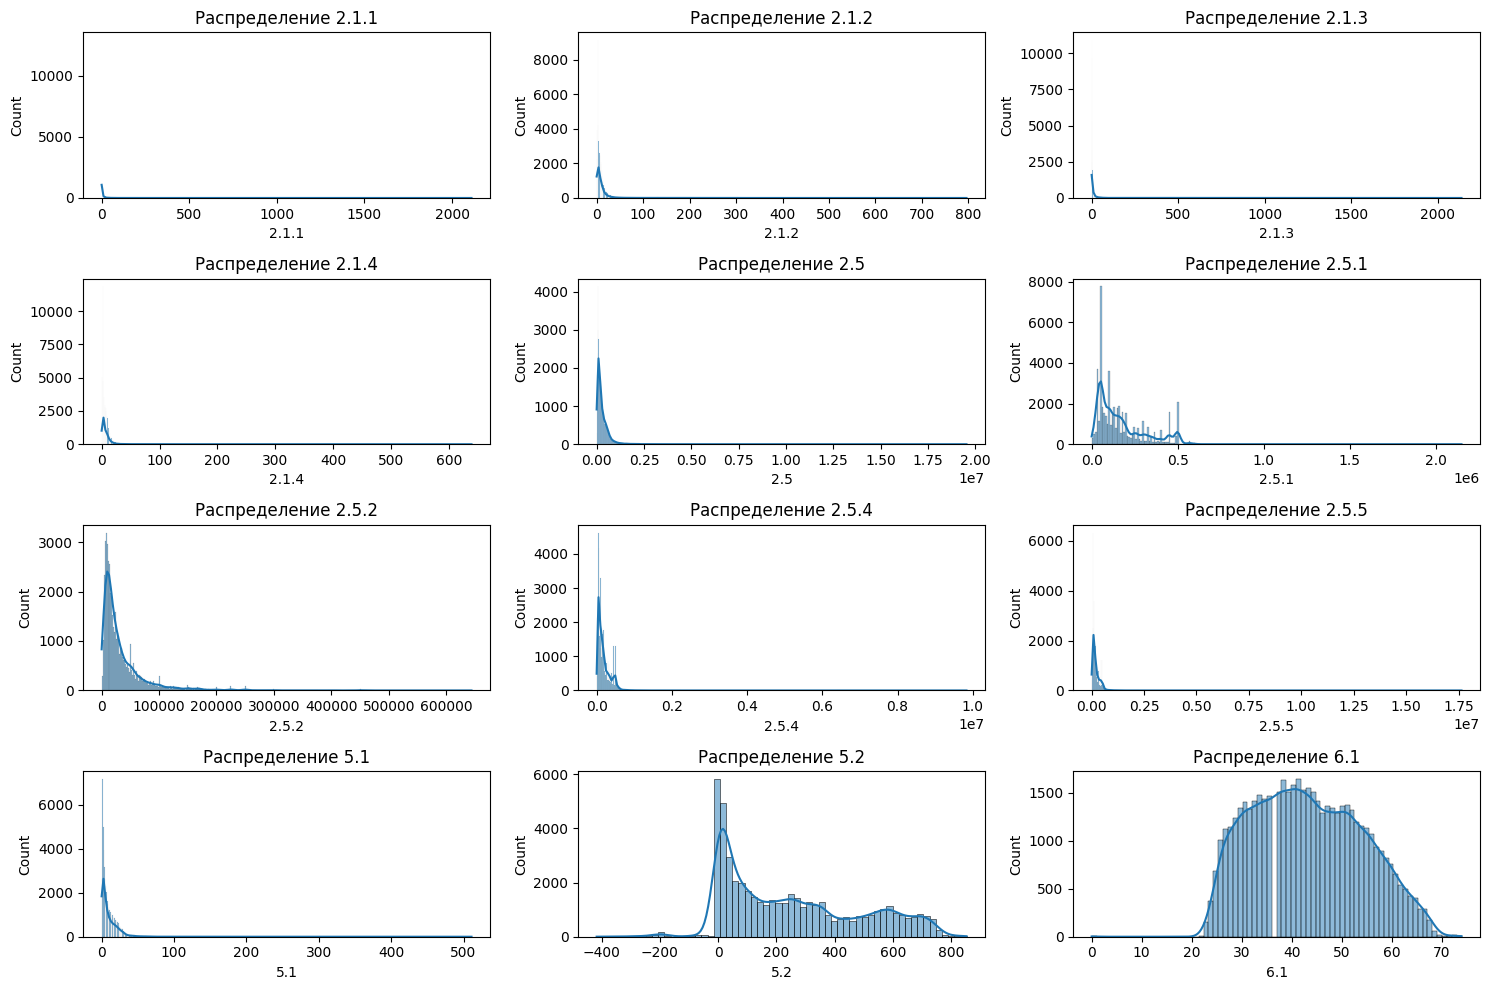

In [ ]:
#Построю гистограммы для числовых столбцов
plt.figure(figsize=(15, 10))
num_cols_to_plot = ['2.1.1', '2.1.2', '2.1.3', '2.1.4', '2.5', '2.5.1', '2.5.2', '2.5.4', '2.5.5', '5.1', '5.2', '6.1']
for i, col in enumerate(num_cols_to_plot, 1):
  plt.subplot(4, 3, i)
  sns.histplot(df[col], kde=True)
  plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

Только распределение по возрасту похоже на нормальное.

/tmp/ipykernel_1367/2034659209.py:9: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


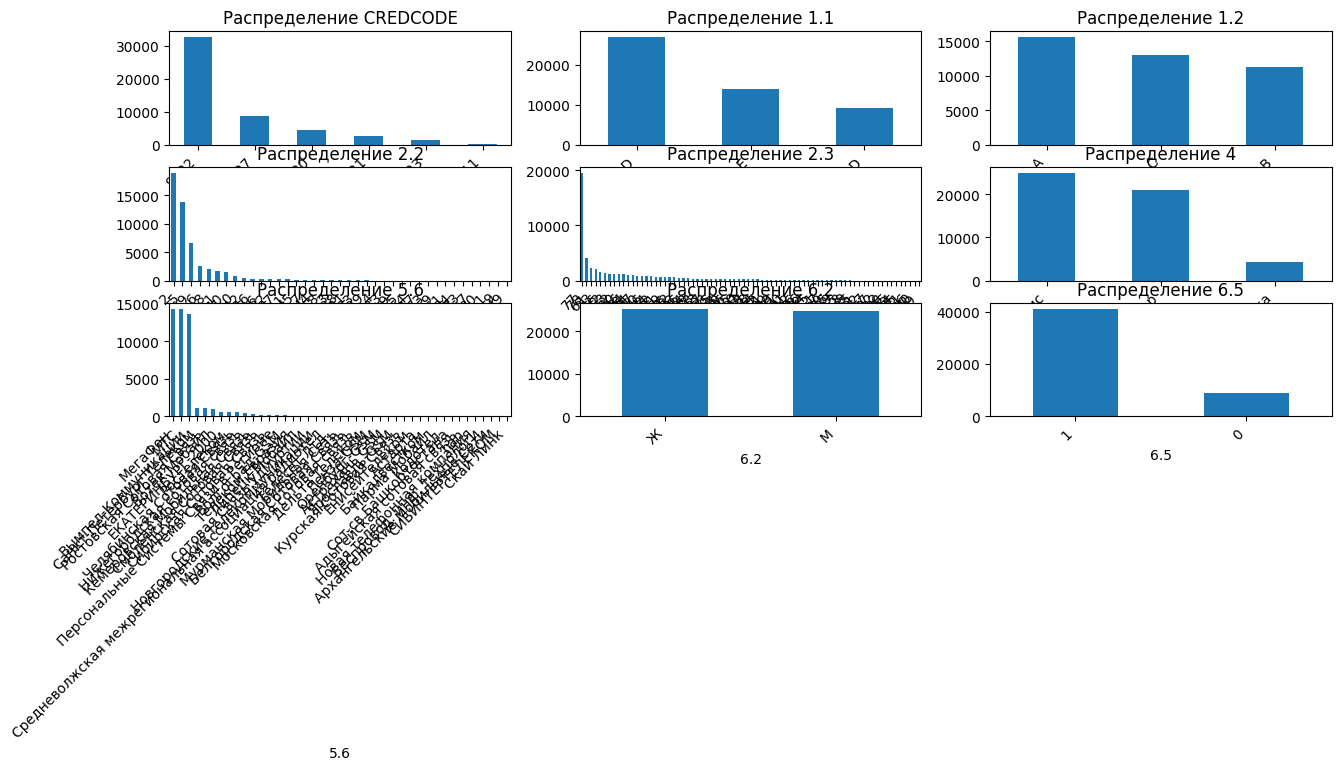

In [ ]:
#Построю столбчатые диаграммы для категориальных столбцов
plt.figure(figsize=(15, 5))
cat_cols_to_plot = ['CREDCODE', '1.1', '1.2', '2.2', '2.3', '4', '5.6', '6.2', '6.5']
for i, col in enumerate(cat_cols_to_plot, 1):
  plt.subplot(3, 3, i)
  df[col].value_counts().plot(kind='bar')
  plt.title(f'Распределение {col}')
  plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Столбец 5.6 "Оператор связи" имеет настолько много значений, что для дальнейшего анализа имеет смысл рассматривать только Мегафон, Вымпел-Коммуникации и Санкт-Петербург Телеком как самые распространенные.

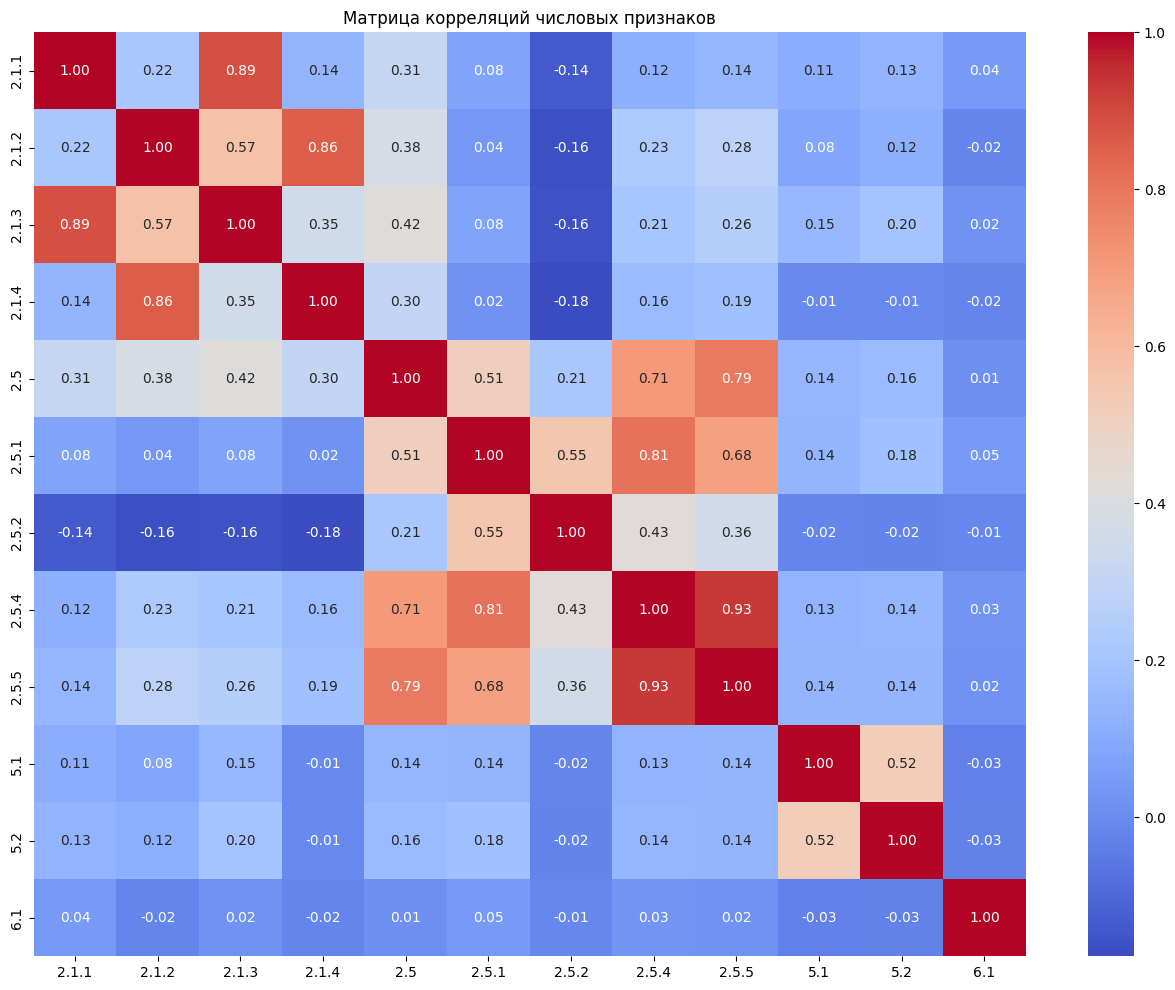

In [ ]:
#Корреляционная матрица для числовых столбцов
plt.figure(figsize=(16, 12))
sns.heatmap(df[['2.1.1', '2.1.2', '2.1.3', '2.1.4', '2.5', '2.5.1', '2.5.2', '2.5.4', '2.5.5', '5.1', '5.2', '6.1']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций числовых признаков')
plt.show()

На основании корреляционной матрицы для числовых столбцов можно сделать следующие выводы:

*   **Высокая положительная корреляция между показателями количества переводов:**
    *   Столбцы `2.1.1` "Количество переводов до 1 смс", `2.1.2` "Количество переводов после 1 смс", `2.1.3` "Количество переводов до взятия кредита" и `2.1.4` "Количество переводов после взятия кредита" имеют сильную положительную корреляцию друг с другом. Это означает, что клиенты, активно совершающие переводы в один период, склонны быть активными и в другие периоды, связанные с отправкой SMS и взятием кредита.

*   **Высокая положительная корреляция между показателями сумм переводов:**
    *   Все столбцы, связанные с суммами переводов (`2.5`, `2.5.1`, `2.5.2`, `2.5.4`, `2.5.5`), демонстрируют очень сильную положительную корреляцию. Это предсказуемо, так как эти метрики описывают одно и то же явление — объём финансовых операций клиента, но с разных сторон (общая сумма, максимальная, средняя, за определенные периоды).

*   **Умеренная корреляция между количеством и суммами переводов:**
    *   Наблюдается умеренная положительная корреляция между группами столбцов, отвечающими за количество переводов (`2.1.i`) и за суммы переводов (`2.5.i`). Это логично: чем больше переводов совершает клиент, тем выше, как правило, и общая сумма его операций.

*   **Корреляция между SMS активностью:**
    *   Столбцы `5.1` "Количество смс до отклика" и `5.2` "Дней с первой смс" показывают умеренную положительную корреляцию. Это может указывать на то, что чем дольше клиент взаимодействует с системой (больше дней с первой SMS), тем больше SMS-сообщений он получает до совершения отклика.

*   **Низкая корреляция с возрастом:**
    *   Столбец `6.1` "Возраст" имеет очень слабые корреляции с большинством других числовых признаков. Это говорит о том, что возраст клиента не является сильным предиктором или следствием его активности по переводам или взаимодействию с SMS.

В целом, матрица корреляций подтверждает интуитивные связи между группами однородных признаков (количество переводов, суммы переводов) и позволяет выявить взаимосвязи между различными типами активности клиентов.

# Поиск взаимосвязей между признаками

In [ ]:
#Заполню пропуски в категориальных столбцах для визуализации
for col in ['1.1', '1.2', '4', '5.6', '6.2']:
  df[col] = df[col].fillna('Неизвестно')

/tmp/ipykernel_1367/2294770794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('Неизвестно')


Взаимосвязи между категориальными и числовыми признаками (box plots)

Text(0, 0.5, 'Возраст (6.1)')

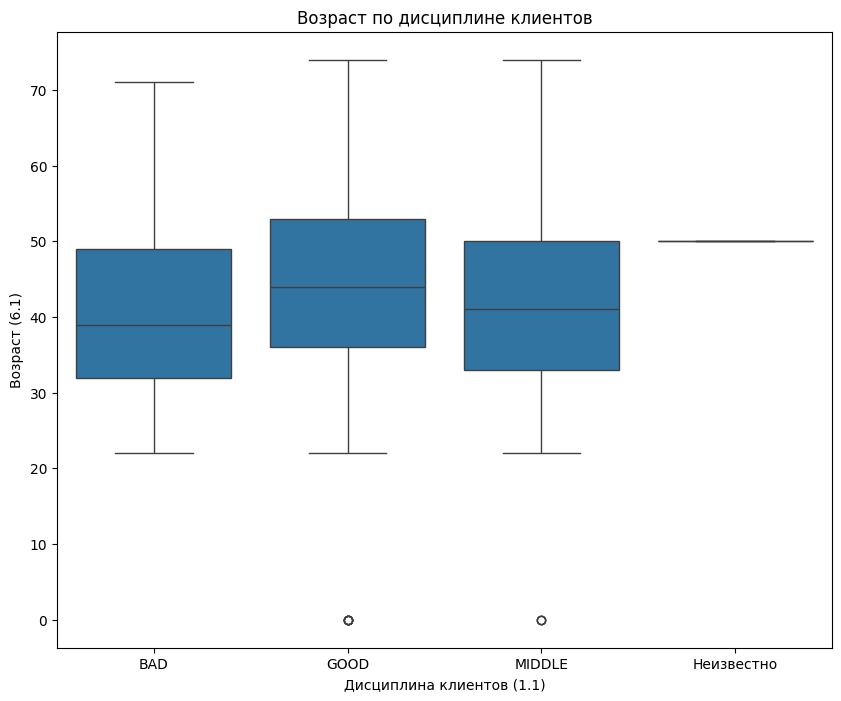

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='1.1', y='6.1', data=df)
plt.title('Возраст по дисциплине клиентов')
plt.xlabel('Дисциплина клиентов (1.1)')
plt.ylabel('Возраст (6.1)')

Чем старше клиент, тем он дисциплинированнее.

Text(0, 0.5, 'Средняя сумма перевода (2.5.2)')

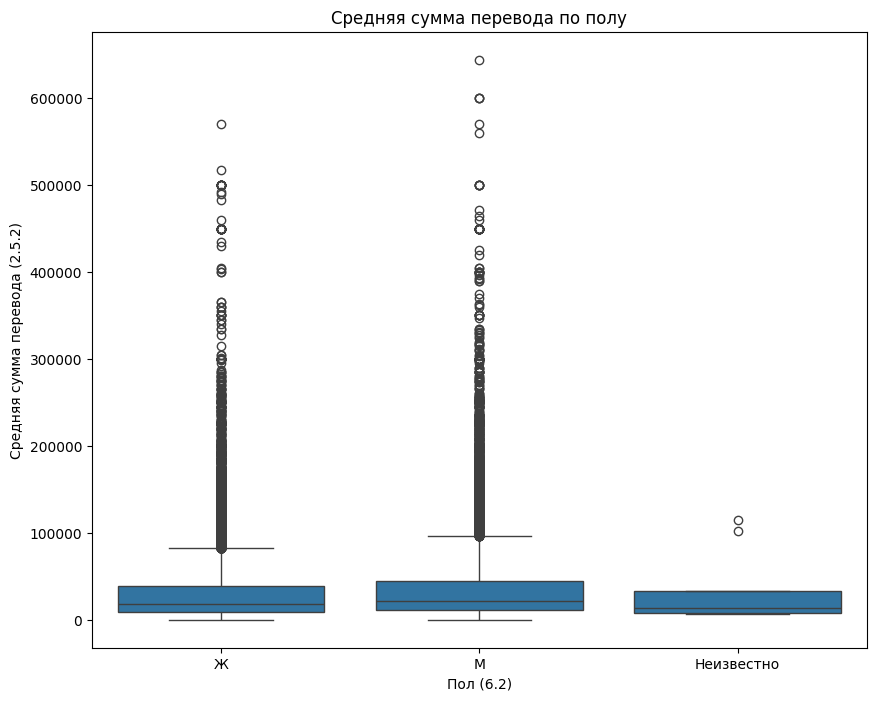

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='6.2', y='2.5.2', data=df.dropna(subset=['2.5.2'])) #удалю строки с NaN в '2.5.2' для чистоты визуализации
plt.title('Средняя сумма перевода по полу')
plt.xlabel('Пол (6.2)')
plt.ylabel('Средняя сумма перевода (2.5.2)')

Средняя сумма перевода практически не зависит от пола.

([0, 1, 2, 3],
 [Text(0, 0, 'Стойка'),
  Text(1, 0, 'Офис'),
  Text(2, 0, 'Партнер'),
  Text(3, 0, 'Неизвестно')])

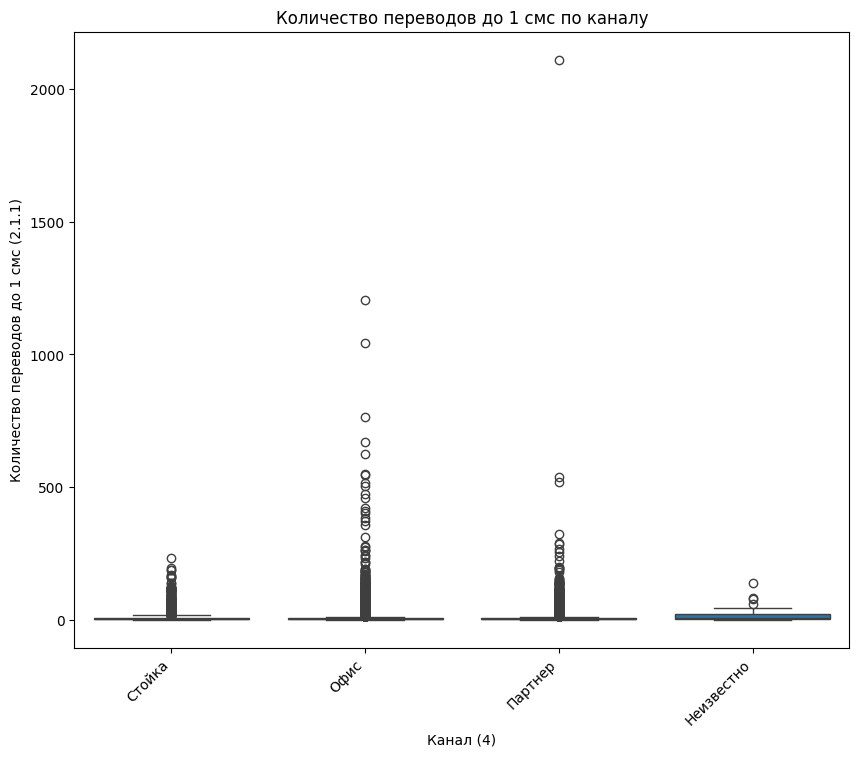

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='4', y='2.1.1', data=df)
plt.title('Количество переводов до 1 смс по каналу')
plt.xlabel('Канал (4)')
plt.ylabel('Количество переводов до 1 смс (2.1.1)')
plt.xticks(rotation=45, ha='right')

Зависимость от канала не прослеживается.

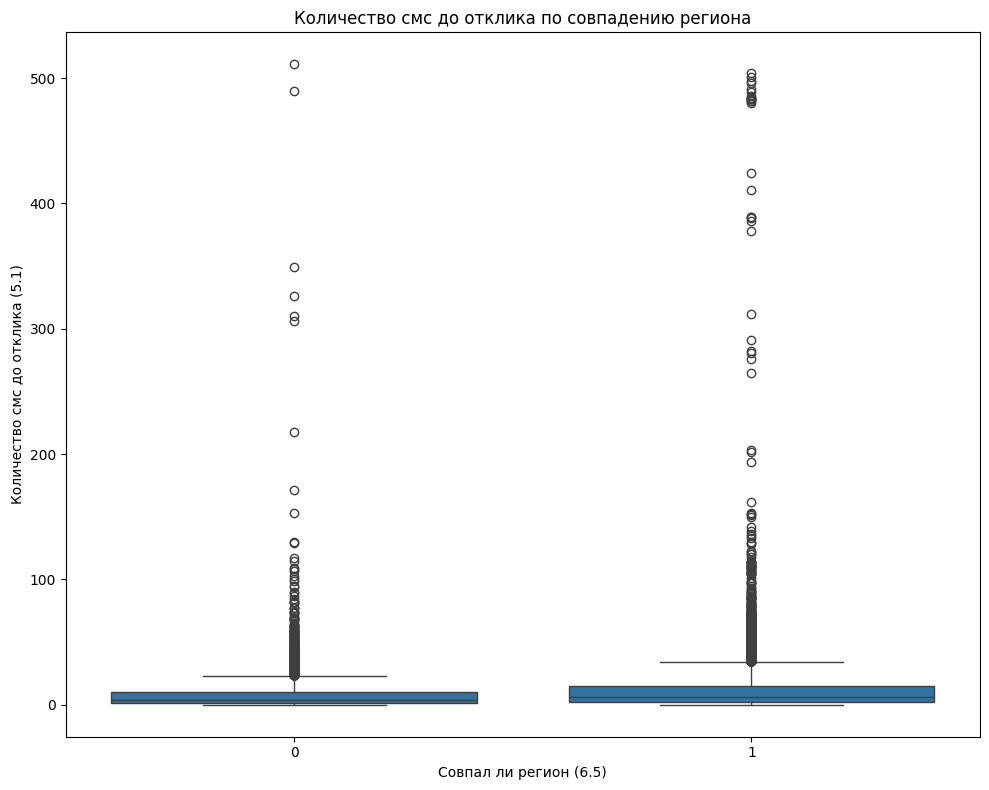

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='6.5', y='5.1', data=df)
plt.title('Количество смс до отклика по совпадению региона')
plt.xlabel('Совпал ли регион (6.5)')
plt.ylabel('Количество смс до отклика (5.1)')
plt.tight_layout()

Зависимость также не прослеживается.

Взаимосвязи между категориальными признаками (crosstab и heatmap)

Text(95.72222222222221, 0.5, 'Дисциплина клиентов (1.1)')

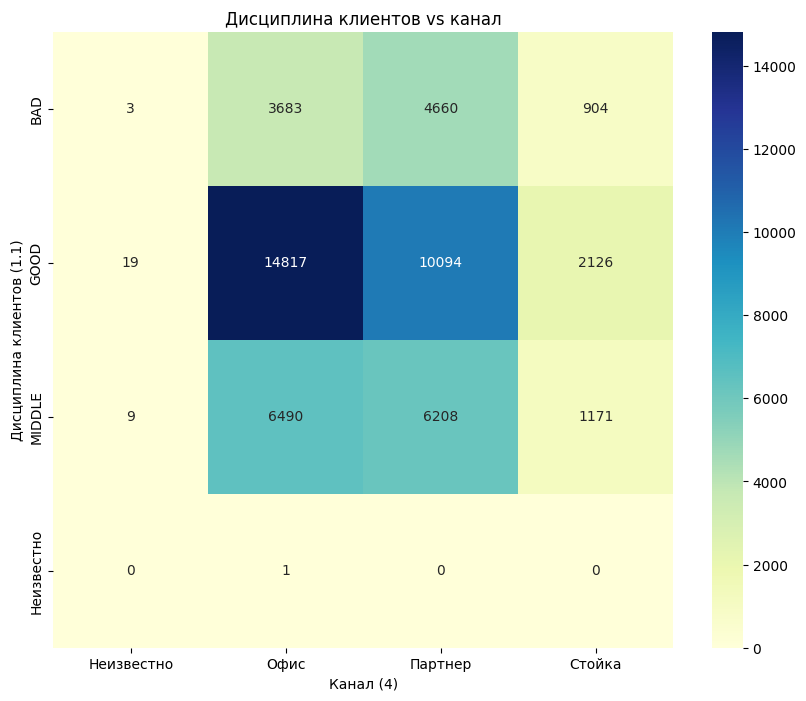

In [ ]:
plt.figure(figsize=(10, 8))
crosstab_1_1_4 = pd.crosstab(df['1.1'], df['4'])
sns.heatmap(crosstab_1_1_4, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Дисциплина клиентов vs канал')
plt.xlabel('Канал (4)')
plt.ylabel('Дисциплина клиентов (1.1)')

Самые дисциплинированные клиенты приходят через офис и от партнера.

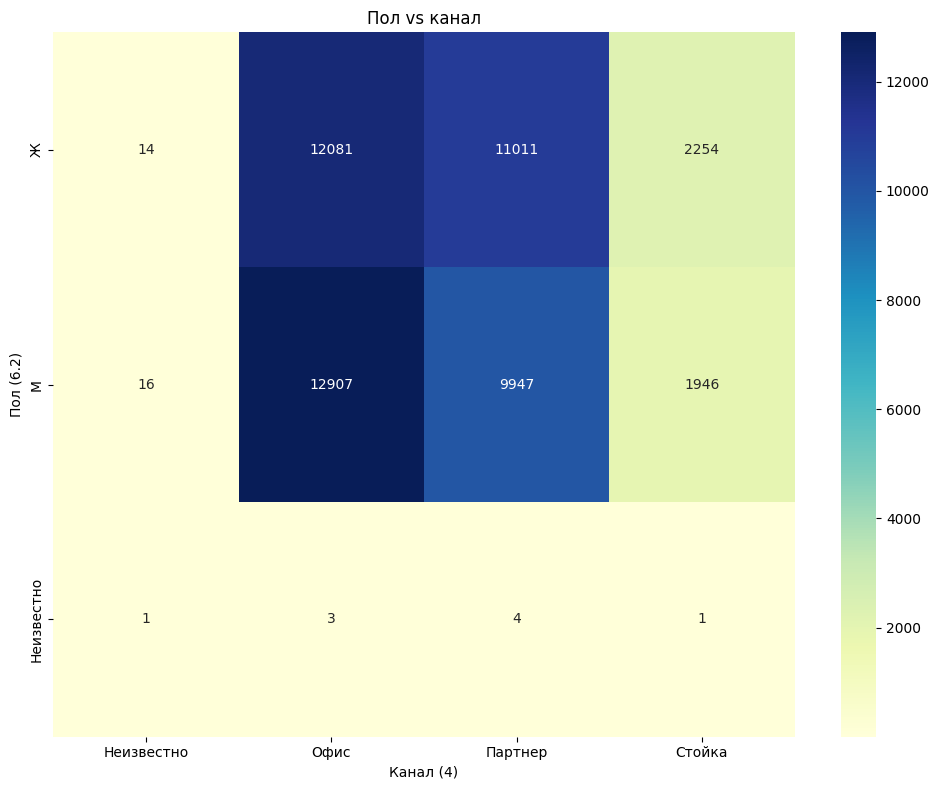

In [ ]:
plt.figure(figsize=(10, 8))
crosstab_6_2_4 = pd.crosstab(df['6.2'], df['4'])
sns.heatmap(crosstab_6_2_4, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Пол vs канал')
plt.xlabel('Канал (4)')
plt.ylabel('Пол (6.2)')

plt.tight_layout()
plt.show()

В офис приходят чуть чаще мужчины, чем женщины. От партнера чуть чаще приходят женщины.

# Кластеризация

In [1]:
#Загрузка очищенного файла
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Data-анализ_2/new_modile.xlsx')

Mounted at /content/drive


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import kruskal, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

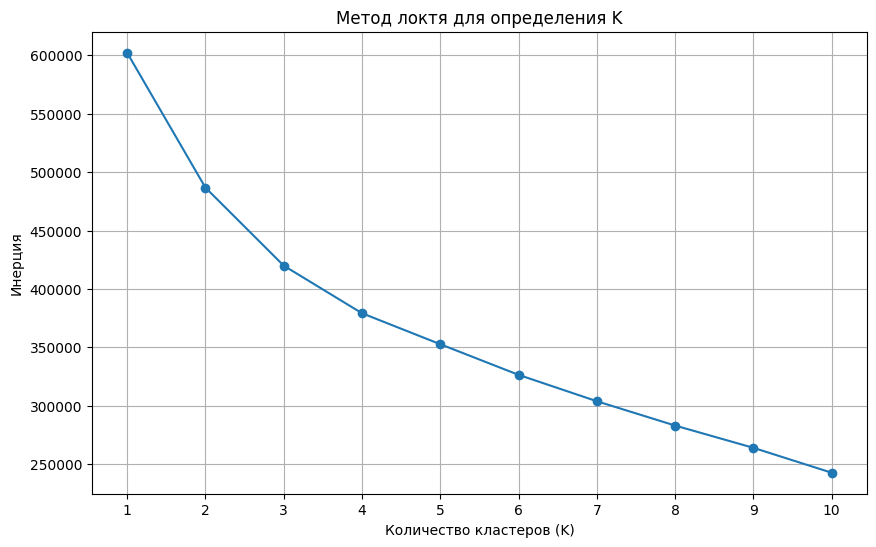

In [4]:
features_for_clustering = ['2.1.1', '2.1.2', '2.1.3', '2.1.4', '2.5', '2.5.1', '2.5.2', '2.5.4', '2.5.5', '5.1', '5.2', '6.1']
categorical_features = ['CREDCODE', '1.1', '1.2', '2.2', '2.3', '4', '5.6', '6.2', '6.5']

#Подготовка данных для кластеризации: обработка NaN и масштабирование
df_clustering = df[features_for_clustering].copy()
df_clustering = df_clustering.fillna(0)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)
df_scaled = pd.DataFrame(df_scaled, columns=features_for_clustering, index=df_clustering.index)

#Метод локтя для определения оптимального количества кластеров
inertia = []
range_k = range(1, 11)  #Подбор от 1 до 10 кластеров

for k in range_k:
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  kmeans.fit(df_scaled)
  inertia.append(kmeans.inertia_)

#Построение графика "Метод локтя"
plt.figure(figsize=(10, 6))
plt.plot(range_k, inertia, marker='o')
plt.title('Метод локтя для определения K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Инерция')
plt.xticks(range_k)
plt.grid(True)
plt.show()

Оптимальное количество кластеров - 4.


Центры кластеров (среднее значение характеристик для каждого кластера):
             2.1.1       2.1.2       2.1.3       2.1.4           2.5  \
Кластер                                                                
0         7.106193    9.516101    9.793323    7.199785  6.819876e+05   
1        10.653715   12.035815   15.574077    7.115453  2.941532e+05   
2         3.452563    6.642754    4.139589    6.500759  1.425495e+05   
3        75.583960  197.142857  171.629073  101.097744  2.138484e+06   

                 2.5.1         2.5.2          2.5.4          2.5.5        5.1  \
Кластер                                                                         
0        407861.647859  84500.489776  447308.886900  477998.475327  10.173613   
1        156865.868450  23440.349539  165763.776332  178549.391111  21.075931   
2         90070.871265  23163.676069   97191.669491  101847.931049   4.486915   
3        194803.513759  10645.913784  556819.302206  811297.251830  16.741855   

       

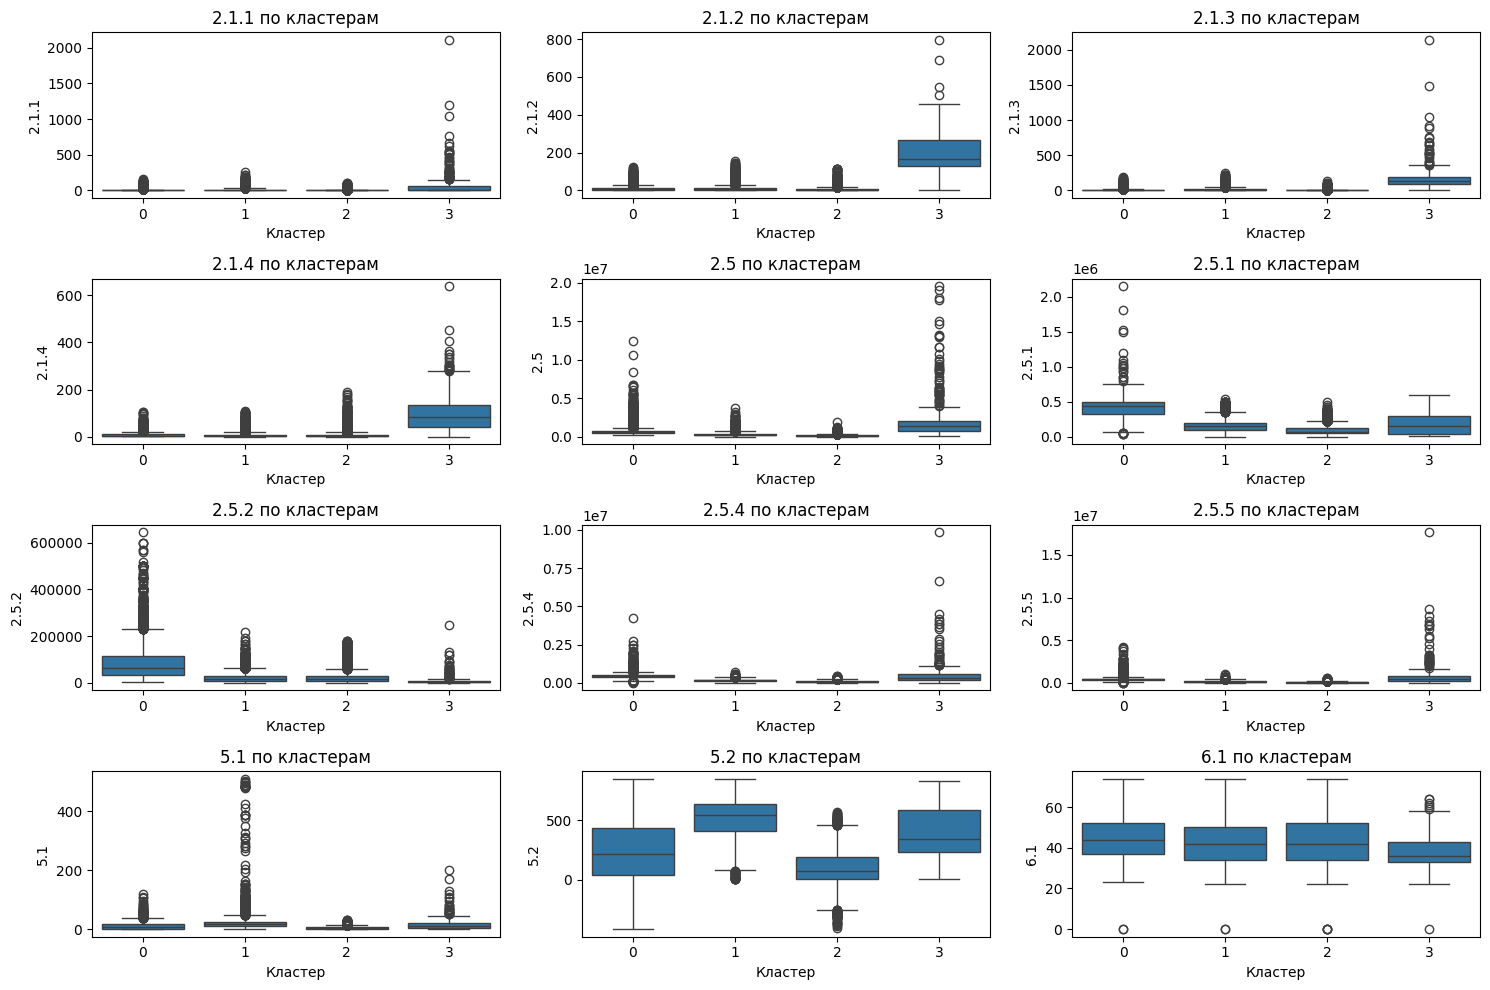

In [5]:
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

df['Кластер'] = cluster_labels

cluster_centers = df.groupby('Кластер')[features_for_clustering].mean()
print("\nЦентры кластеров (среднее значение характеристик для каждого кластера):")
print(cluster_centers)

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_for_clustering, 1):
  plt.subplot(4, 3, i)
  sns.boxplot(x='Кластер', y=col, data=df)
  plt.title(f'{col} по кластерам')
plt.tight_layout()
plt.show()

In [6]:
#Размеры кластеров
df['Кластер'].value_counts(normalize=True)

,proportion
Кластер,
2,0.538308
1,0.268726
0,0.185015
3,0.007951


In [7]:
clustered_dfs = {}
for cluster_num in sorted(df['Кластер'].unique()):
  clustered_dfs[cluster_num] = df[df['Кластер'] == cluster_num].copy()
  print(f"Кластер {cluster_num} имеет {len(clustered_dfs[cluster_num])} записей")

print("\nДатафрейм для Кластера 0 (первые 5 строк):\n")
print(clustered_dfs[0].head())
print("\nДатафрейм для Кластера 1 (первые 5 строк):\n")
print(clustered_dfs[1].head())
print("\nДатафрейм для Кластера 2 (первые 5 строк):\n")
print(clustered_dfs[2].head())
print("\nДатафрейм для Кластера 3 (первые 5 строк):\n")
print(clustered_dfs[3].head())

Кластер 0 имеет 9285 записей
Кластер 1 имеет 13486 записей
Кластер 2 имеет 27015 записей
Кластер 3 имеет 399 записей

Датафрейм для Кластера 0 (первые 5 строк):

     mdm_id   BIRTHDAY  CREDCODE     1.1 1.2  2.1.1  2.1.2  2.1.3  2.1.4  2.2  \
7   3882794 1979-05-20      9022     BAD   A      0      0     13      2    5   
10  3331272 1964-02-06      9022  MIDDLE   A      0      0      3      1    2   
24  6802710 1987-10-18      9022     BAD   C      0      0      0      2   69   
40  6130883 1952-10-19      9022     BAD   C      0      0     10      2    5   
49  7552875 1954-01-06      9022     BAD   B      0      0      0      8    1   

    ...     2.5.4     2.5.5        4  5.1  5.2  5.6 6.1  6.2  6.5 Кластер  
7   ...  400150.0  400150.0   Стойка    0    0  NaN  35    Ж    1       0  
10  ...  500000.0  500000.0     Офис    0    0  NaN  50    Ж    1       0  
24  ...  450150.0  450150.0     Офис    0    0  NaN  26    М    1       0  
40  ...  390000.0  400000.0  Партнер    0    0 

In [8]:
import os

#Создание директории для сохранения кластерных датафреймов
output_dir = "clustered_dataframes"
os.makedirs(output_dir, exist_ok=True)

#Сохранение каждого кластерного датафрейма в отдельный файл Excel
for cluster_num, df_cluster in clustered_dfs.items():
  file_name = os.path.join(output_dir, f"cluster_{cluster_num}.xlsx")
  df_cluster.to_excel(file_name, index=False)
  print(f"Кластер {cluster_num} сохранен в файл: {file_name}")

print(f"\nВсе кластеры сохранены в директорию: {output_dir}")

Кластер 0 сохранен в файл: clustered_dataframes/cluster_0.xlsx
Кластер 1 сохранен в файл: clustered_dataframes/cluster_1.xlsx
Кластер 2 сохранен в файл: clustered_dataframes/cluster_2.xlsx
Кластер 3 сохранен в файл: clustered_dataframes/cluster_3.xlsx

Все кластеры сохранены в директорию: clustered_dataframes


In [9]:
#Проверка гипотез для числовых характеристик (критерий Краскела-Уоллиса)
print("\nТесты Краскела-Уоллиса для числовых признаков")
for feature in features_for_clustering:
  cluster_data = [df[df['Кластер'] == c][feature].dropna() for c in sorted(df['Кластер'].unique())]
  valid_cluster_data = [data for data in cluster_data if len(data) > 0]

  if len(valid_cluster_data) >= 2:
    stat, p = kruskal(*valid_cluster_data)
    print(f"Признак '{feature}': H-статистика={stat:.2f}, p-значение={p:.3f}")
    if p < 0.05:
      print(f"\tОбнаружены статистически значимые различия между кластерами для признака '{feature}'.")
    else:
      print(f"\tСтатистически значимых различий между кластерами для признака '{feature}' не обнаружено.")
  else:
    print(f"Признак '{feature}': Недостаточно данных для теста Краскела-Уоллиса (менее 2 кластеров имеют данные).")


Тесты Краскела-Уоллиса для числовых признаков
Признак '2.1.1': H-статистика=6232.16, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '2.1.1'.
Признак '2.1.2': H-статистика=2792.17, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '2.1.2'.
Признак '2.1.3': H-статистика=8748.85, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '2.1.3'.
Признак '2.1.4': H-статистика=1020.38, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '2.1.4'.
Признак '2.5': H-статистика=24652.66, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '2.5'.
Признак '2.5.1': H-статистика=25785.50, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '2.5.1'.
Признак '2.5.2': H-статистика=12536.79, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для

In [10]:
#Проверка гипотез для категориальных признаков (критерий хи-квадрат)
print("\nХи-квадрат-тесты для категориальных признаков")
for feature in categorical_features:
  contingency_table = pd.crosstab(df['Кластер'], df[feature])
  if contingency_table.sum().sum() > 0 and contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
    contingency_table = contingency_table.loc[:, (contingency_table != 0).any(axis=0)]
    contingency_table = contingency_table.loc[(contingency_table != 0).any(axis=1), :]

  if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Признак '{feature}': Хи-квадрат={chi2:.2f}, p-значение={p:.3f}")
    if p < 0.05:
      print(f"\tОбнаружены статистически значимые различия между кластерами для признака '{feature}'.")
    else:
      print(f"\tСтатистически значимых различий между кластерами для признака '{feature}' не обнаружено.")
  else:
    print(f"Признак '{feature}': Недостаточно вариаций в данных для Хи-квадрат теста после очистки.")


Хи-квадрат-тесты для категориальных признаков
Признак 'CREDCODE': Хи-квадрат=11994.59, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака 'CREDCODE'.
Признак '1.1': Хи-квадрат=1153.18, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '1.1'.
Признак '1.2': Хи-квадрат=496.40, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '1.2'.
Признак '2.2': Хи-квадрат=6996.97, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '2.2'.
Признак '2.3': Хи-квадрат=4626.81, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '2.3'.
Признак '4': Хи-квадрат=1747.57, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '4'.
Признак '5.6': Хи-квадрат=1682.83, p-значение=0.000
	Обнаружены статистически значимые различия между кластерами для признака '5.6'.
Признак '6.2': Х

# Выводы по статистическим тестам
По всем числовым признакам отвергается нулевая гипотеза, что медианы всех кластеров одинаковы. Это означает, что все кластеры отличаются друг от друга по каждому числовому признаку.
По всем категориальным признакам отвергается нулевая гипотеза о независимости признака от кластера. Это означает, что распределение каждого категориального признака значительно различается между кластерами.

# Профили кластеров

In [11]:
for cluster_num in sorted(df['Кластер'].unique()):
  print(f"--- Кластер {cluster_num} ---")

  #Анализ числовых характеристик
  print("\nСредние значения числовых характеристик:")
  print(cluster_centers.loc[cluster_num].round(2))

  #Анализ категориальных характеристик
  df_cluster = clustered_dfs[cluster_num]
  print("\nРаспределение категориальных характеристик:")
  for col in ['CREDCODE', '1.1', '1.2', '2.2', '2.3', '4', '5.6', '6.2', '6.5']:
    if col in df_cluster.columns:
      print(f"\t{col}:\n{df_cluster[col].value_counts(normalize=True).round(2)}\n")

--- Кластер 0 ---

Средние значения числовых характеристик:
2.1.1         7.11
2.1.2         9.52
2.1.3         9.79
2.1.4         7.20
2.5      681987.59
2.5.1    407861.65
2.5.2     84500.49
2.5.4    447308.89
2.5.5    477998.48
5.1          10.17
5.2         257.68
6.1          44.14
Name: 0, dtype: float64

Распределение категориальных характеристик:
	CREDCODE:
CREDCODE
9022    0.69
9027    0.22
9021    0.04
9020    0.03
9023    0.02
9011    0.00
Name: proportion, dtype: float64

	1.1:
1.1
GOOD      0.57
MIDDLE    0.26
BAD       0.17
Name: proportion, dtype: float64

	1.2:
1.2
A    0.38
C    0.31
B    0.31
Name: proportion, dtype: float64

	2.2:
2.2
 2     0.36
 5     0.28
 69    0.13
 6     0.06
 8     0.05
 10    0.04
 1     0.02
 32    0.01
 0     0.01
 12    0.01
 26    0.01
 37    0.01
 11    0.01
 7     0.00
 16    0.00
 45    0.00
 58    0.00
 3     0.00
 44    0.00
 33    0.00
 54    0.00
 29    0.00
 59    0.00
 17    0.00
 61    0.00
-1     0.00
 9     0.00
 28    0.00
Na

`Название и описание кластера 0`

# Умеренные пользователи
Этот кластер характеризуется умеренным количеством переводов (как до, так и после кредита), но при этом имеет очень высокие средние, максимальные и общие суммы переводов. Активность по SMS умеренная, период с первой SMS довольно длительный. Средний возраст клиентов составляет около 44 лет. Среди них преобладают клиенты с хорошей и средней дисциплиной. Чаще приходят через офис и партнера. Регионы телефона и переводов в большинстве случаев совпадают. Это клиенты, которые совершают стабильное количество операций с крупными суммами.

`Название и описание кластера 1`

# Активные пользователи
В этом кластере наблюдается относительно высокое количество переводов по всем показателям, а также значительные средние и максимальные суммы переводов. Они демонстрируют самую высокую активность по SMS и самый длительный период с первой SMS, что указывает на их высокую вовлеченность. Средний возраст клиентов составляет около 43 лет. Дисциплина клиентов здесь смешанная, но с существенной долей хорошей дисциплины. Эти клиенты, вероятно, являются наиболее лояльными и активно взаимодействуют с платежной системой.

`Название и описание кластера 2`

# Пассивные наблюдатели
Это самый многочисленный кластер, характеризующийся наименьшим количеством переводов по всем показателям и самыми низкими суммами переводов. У них также наименьшая активность по SMS и короткий период с первой SMS. Средний возраст клиентов составляет около 43 лет. Значительная часть клиентов классифицируется как с плохой или неизвестной дисциплиной. Многие приходят через стойку и офис. Этот кластер, скорее всего, включает новых клиентов или клиентов с очень низкой активностью, которые, возможно, брали кредиты, но мало пользовались системой для переводов.

`Название и описание кластера 3`

# Темные лошадки
Самый мелкий, но очень активный кластер. Его клиенты совершают чрезвычайно большое количество переводов по всем показателям, имеют высокую общую сумму переводов и значительные суммы за полгода/год до кредита. Однако их средняя сумма перевода самая низкая, что указывает на множество мелких транзакций. Это самый молодой кластер, средний возраст клиентов около 38 лет. Они проявляют высокую активность по SMS. Дисциплина клиентов преимущественно средняя и хорошая. Среди них больше мужчин, а регионы телефона и переводов часто не совпадают. Эти клиенты активно используют систему для частых, но небольших операций.